# Exploratory Data Analysis

## Project

**The Geography of AI Innovation**

---

### Research Question

Why do some countries become AI research leaders while others do not?

---

This notebook explores the merged country-year dataset created from OpenAlex and World Bank data. The goal is to identify patterns in global AI research output, citation impact, collaboration, and socioeconomic indicators.

# 1. Load the Dataset

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "master_country_year.csv"
)

df.head()

,country_code_x,year,ai_papers,total_citations,avg_citations_per_paper,median_citations_per_paper,avg_authors_per_paper,avg_institutions_per_paper,international_collaboration_rate,country_code_iso3,country_name,country_code_y,gdp_current_usd,population,rd_expenditure_percent_gdp,education_expenditure_percent_gdp,internet_users_percent,gdp_per_capita_current_usd
0,AE,2017,1,673,673.0000,673.0,3.0000,2.0000,1.0000,ARE,United Arab Emirates,ARE,4.033650e+11,9223225.0,NaN,NaN,94.819923,43733.619229
1,AE,2018,3,2305,768.3333,739.0,4.3333,3.3333,1.0000,ARE,United Arab Emirates,ARE,4.405601e+11,9346701.0,1.26389,NaN,98.450002,47135.359194
2,AE,2019,6,6777,1129.5000,986.0,10.1667,6.5000,1.0000,ARE,United Arab Emirates,ARE,4.339262e+11,9445785.0,1.31065,3.86020,99.149998,45938.607358
3,AE,2020,9,9247,1027.4444,863.0,5.5556,3.3333,0.8889,ARE,United Arab Emirates,ARE,3.571619e+11,9401038.0,1.48831,3.98418,100.000000,37991.749297
4,AE,2021,14,13623,973.0714,757.5,5.3571,5.0714,0.9286,ARE,United Arab Emirates,ARE,4.224414e+11,9575152.0,1.49469,3.89404,100.000000,44118.504719


# 2. AI Research Output by Country

### Research Question

Which countries produce the highest number of AI publications?

In [9]:
country_output = (
    df.groupby("country_name")["ai_papers"]
      .sum()
      .sort_values(ascending=False)
)

country_output.head(10)

country_name
United States           3949
China                   2799
United Kingdom          1444
Germany                  916
Australia                752
Canada                   686
India                    473
Hong Kong SAR, China     449
France                   432
Singapore                409
Name: ai_papers, dtype: int64

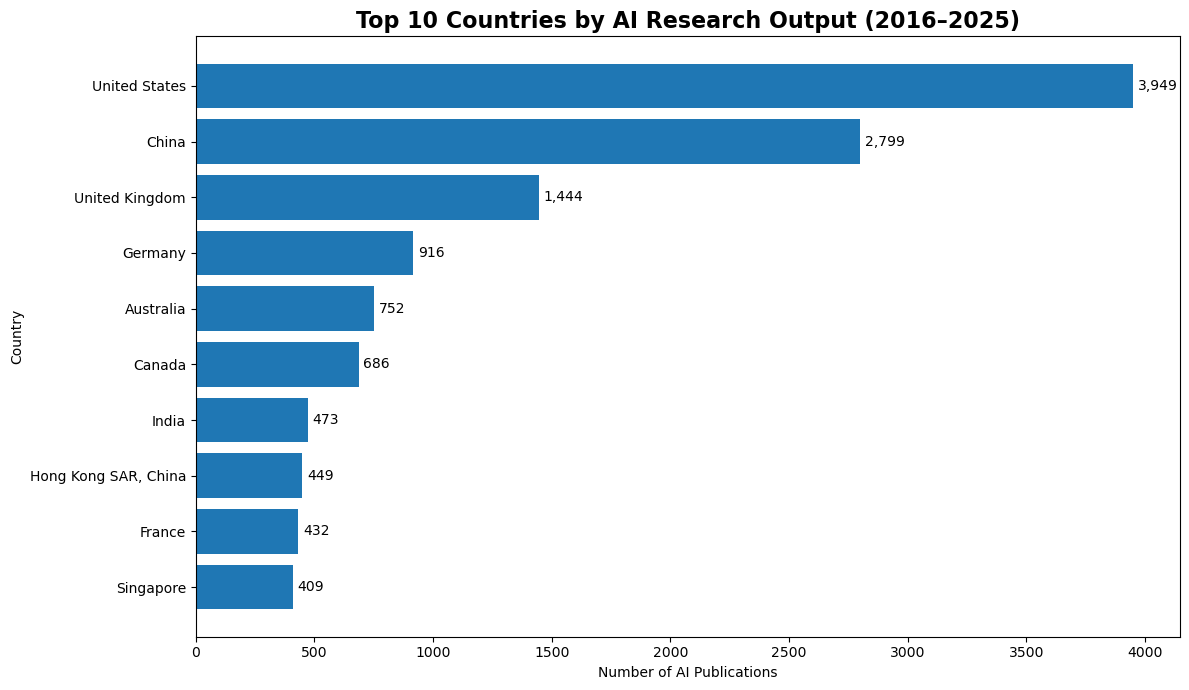

In [10]:
top10 = country_output.head(10).sort_values()

plt.figure(figsize=(12, 7))

bars = plt.barh(top10.index, top10.values)

plt.title(
    "Top 10 Countries by AI Research Output (2016–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of AI Publications")
plt.ylabel("Country")

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [11]:
total_papers = country_output.sum()

top10_papers = country_output.head(10).sum()

top10_share = top10_papers / total_papers

print(f"Total AI papers: {total_papers:,}")
print(f"Top 10 papers: {top10_papers:,}")
print(f"Top 10 share: {top10_share:.2%}")

Total AI papers: 18,240
Top 10 papers: 12,309
Top 10 share: 67.48%


In [12]:
usa_share = country_output.loc["United States"] / total_papers
china_share = country_output.loc["China"] / total_papers

print(f"USA share: {usa_share:.2%}")
print(f"China share: {china_share:.2%}")
print(f"Combined share: {(usa_share + china_share):.2%}")

USA share: 21.65%
China share: 15.35%
Combined share: 37.00%


### Key Findings

- The dataset contains **18,240 AI publications** between 2016 and 2025.
- The **top 10 countries** account for **67.48%** of all AI publications.
- The **United States** is the largest contributor, producing **21.65%** of all publications.
- **China** contributes **15.35%** of all publications.
- Together, the United States and China produce **37.00%** of the AI research represented in the dataset.

### Interpretation

AI research output is highly concentrated among a relatively small number of countries. Although the dataset includes 134 countries, over two-thirds of all AI publications originate from only ten countries, while the United States and China alone account for more than one-third of total output. This suggests that global AI research capacity is unevenly distributed, with a small group of countries acting as the primary drivers of scientific production.


# 3. AI Research Output Relative to Population

### Research Question

Which countries produce the most AI research relative to their population size?

In [13]:
# Calculate AI papers per million inhabitants

df["ai_papers_per_million"] = (
    df["ai_papers"] /
    (df["population"] / 1_000_000)
)

In [14]:
papers_per_million = (
    df.groupby("country_name")["ai_papers_per_million"]
      .mean()
      .sort_values(ascending=False)
)

papers_per_million.head(15)

country_name
Cayman Islands               28.757693
Gibraltar                    27.131152
Liechtenstein                25.528645
Sint Maarten (Dutch part)    23.068051
Bermuda                      15.760690
Antigua and Barbuda          10.716276
Singapore                     7.141366
Hong Kong SAR, China          5.994406
Macao SAR, China              5.443197
Switzerland                   4.493328
Iceland                       4.409344
Barbados                      3.542105
Finland                       2.987412
Australia                     2.925098
Luxembourg                    2.683354
Name: ai_papers_per_million, dtype: float64

In [15]:
df_large = df[df["population"] >= 1_000_000]

In [16]:
papers_per_million = (
    df_large.groupby("country_name")["ai_papers_per_million"]
            .mean()
            .sort_values(ascending=False)
)

papers_per_million.head(15)

country_name
Singapore               7.141366
Hong Kong SAR, China    5.994406
Switzerland             4.493328
Finland                 2.987412
Australia               2.925098
Norway                  2.450983
Denmark                 2.372710
United Kingdom          2.209786
Sweden                  2.143084
Qatar                   2.117318
Netherlands             2.093633
Israel                  1.906668
Canada                  1.811601
Ireland                 1.809784
Austria                 1.781902
Name: ai_papers_per_million, dtype: float64

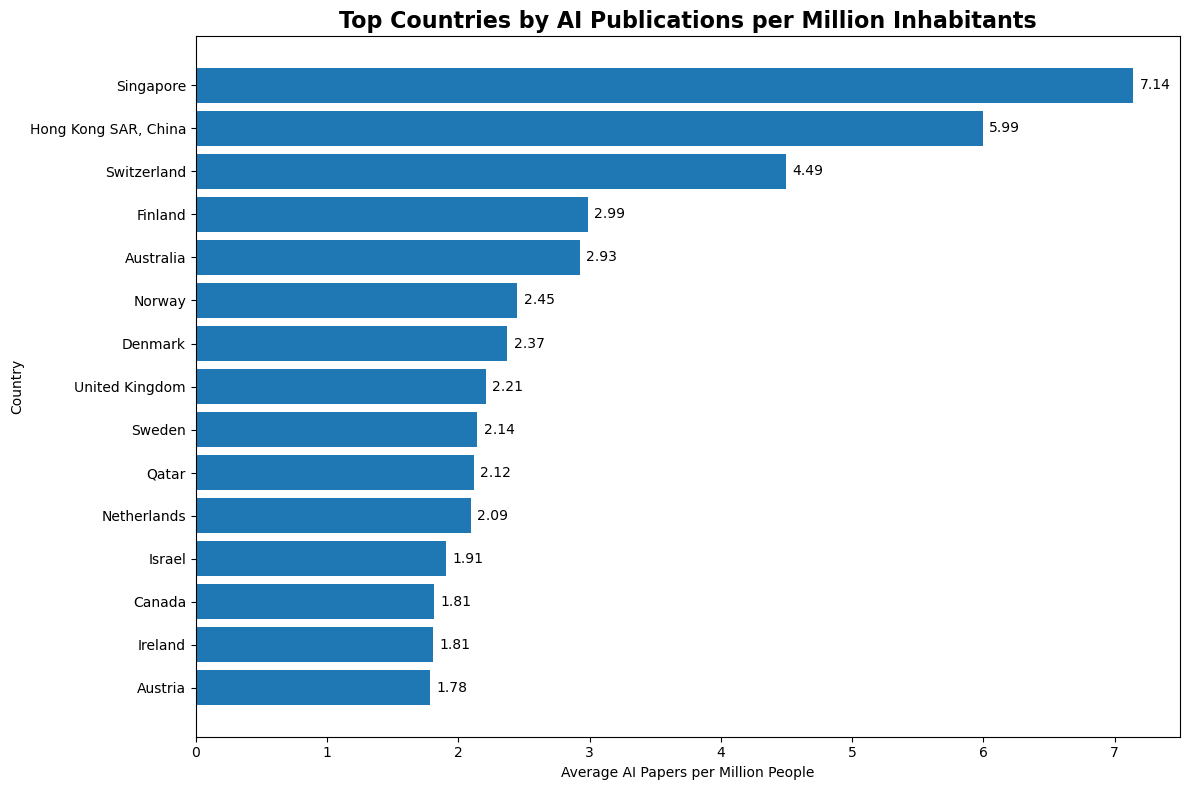

In [17]:
top15 = papers_per_million.head(15).sort_values()

plt.figure(figsize=(12,8))

bars = plt.barh(top15.index, top15.values)

plt.title(
    "Top Countries by AI Publications per Million Inhabitants",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average AI Papers per Million People")
plt.ylabel("Country")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Key Findings

- After adjusting for population size, Singapore ranks first in AI research productivity.
- Several smaller, high-income economies—including Switzerland, Finland, Norway, and Denmark—appear among the global leaders.
- The United States and China, despite leading in total publication output, do not rank among the top countries on a per-capita basis.
- Population-normalized metrics reveal a different perspective on AI research capacity than raw publication counts.

### Interpretation

Normalizing AI publications by population changes the ranking considerably. While the United States and China dominate global AI research in absolute numbers, smaller countries such as Singapore and Switzerland produce substantially more AI publications relative to their population size. This suggests that research intensity is not solely determined by country size, but also by factors such as research investment, institutional quality, and innovation ecosystems.

# 4. AI Research Impact

### Research Question

Which countries produce the highest-impact AI research?

### Why this matters

Publishing many papers does not necessarily mean producing influential research. Citation counts provide a proxy for scientific impact by measuring how often publications are referenced by other researchers.

In [18]:
df["avg_citations_per_paper"].describe()

count      831.00000
mean       840.39373
std        883.12032
min         51.00000
25%        368.85715
50%        690.20590
75%       1050.32500
max      11183.35290
Name: avg_citations_per_paper, dtype: float64

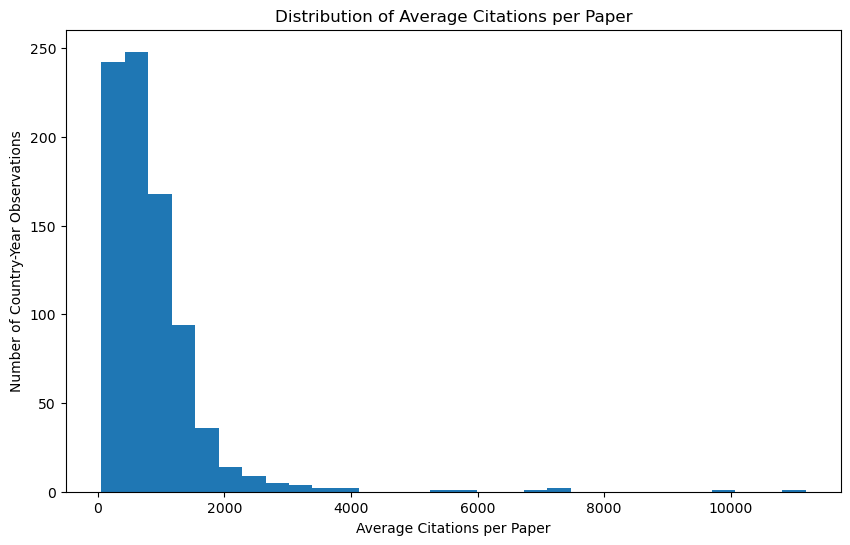

In [19]:
plt.figure(figsize=(10,6))

plt.hist(
    df["avg_citations_per_paper"],
    bins=30
)

plt.title("Distribution of Average Citations per Paper")

plt.xlabel("Average Citations per Paper")
plt.ylabel("Number of Country-Year Observations")

plt.show()

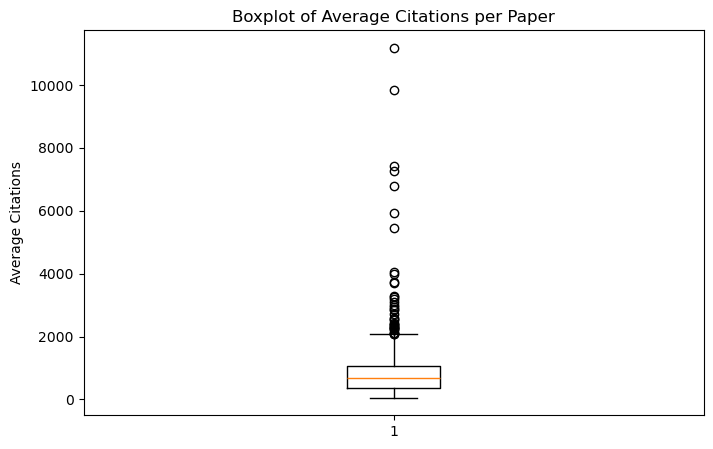

In [20]:
plt.figure(figsize=(8,5))

plt.boxplot(df["avg_citations_per_paper"])

plt.title("Boxplot of Average Citations per Paper")

plt.ylabel("Average Citations")

plt.show()

### Method

To reduce the influence of extreme citation outliers, both the mean and median average citations per paper were calculated for each country. Comparing both measures provides a more robust assessment of research impact.

In [21]:
citation_stats = (
    df.groupby("country_name")
      .agg(
          mean_citations=("avg_citations_per_paper", "mean"),
          median_citations=("avg_citations_per_paper", "median"),
          observations=("avg_citations_per_paper", "count")
      )
      .sort_values("mean_citations", ascending=False)
)

citation_stats.head(15)

,mean_citations,median_citations,observations
country_name,,,
Panama,2578.000000,2578.00000,1
Israel,2038.157910,1079.70485,10
Iceland,1755.928571,857.00000,7
Czechia,1611.482380,726.80000,10
Austria,1606.806090,1376.08890,10
New Zealand,1452.505950,842.82855,10
Romania,1451.923330,877.41665,10
Ireland,1371.207290,767.41560,10
Cuba,1332.000000,1332.00000,1


In [22]:
citation_stats.sort_values(
    "median_citations",
    ascending=False
).head(15)

,mean_citations,median_citations,observations
country_name,,,
Panama,2578.00000,2578.00000,1
Austria,1606.80609,1376.08890,10
Cuba,1332.00000,1332.00000,1
Peru,1308.50000,1308.50000,2
Germany,1122.35917,1307.77280,10
Tajikistan,1213.00000,1213.00000,1
Dominican Republic,1195.00000,1195.00000,1
United Kingdom,1187.43148,1169.24085,10
Australia,978.78688,1113.74000,10


In [23]:
citation_filtered = (
    citation_stats[
        citation_stats["observations"] >= 5
    ]
)

citation_filtered.sort_values(
    "median_citations",
    ascending=False
).head(15)

,mean_citations,median_citations,observations
country_name,,,
Austria,1606.80609,1376.08890,10
Germany,1122.35917,1307.77280,10
United Kingdom,1187.43148,1169.24085,10
Australia,978.78688,1113.74000,10
France,1192.26660,1092.59915,10
Israel,2038.15791,1079.70485,10
United States,1105.90843,1072.93815,10
Japan,837.62971,1014.49820,10
"Korea, Rep.",1037.78842,999.07085,10


# 5. Relationship Between GDP and AI Research Output

### Research Question

Is there a relationship between a country's economic size and its AI research output?

### Why this matters

AI research requires funding, infrastructure, universities, and private investment. Gross Domestic Product (GDP) is often used as a proxy for a country's economic capacity. Understanding whether GDP is associated with AI research output helps determine whether wealth alone explains global AI research leadership.

In [24]:
gdp_df = df.dropna(
    subset=["gdp_current_usd", "ai_papers"]
)

print(len(gdp_df))

709


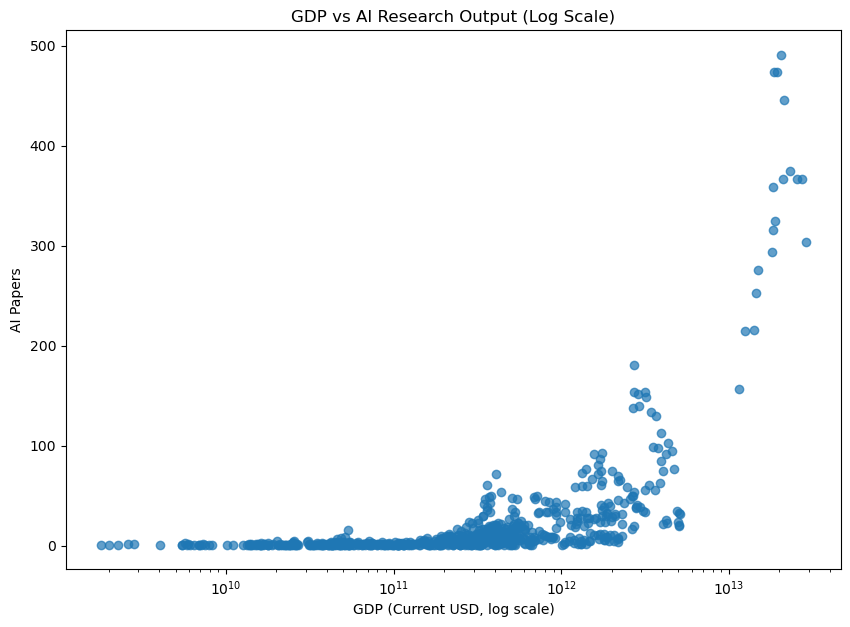

In [25]:
plt.figure(figsize=(10,7))

plt.scatter(
    gdp_df["gdp_current_usd"],
    gdp_df["ai_papers"],
    alpha=0.7
)

plt.xscale("log")

plt.title("GDP vs AI Research Output (Log Scale)")

plt.xlabel("GDP (Current USD, log scale)")
plt.ylabel("AI Papers")

plt.show()

In [26]:
correlation = gdp_df["gdp_current_usd"].corr(
    gdp_df["ai_papers"]
)

print(f"Pearson correlation: {correlation:.3f}")

Pearson correlation: 0.926


# 6. Countries that Overperform Relative to GDP

### Research Question

Which countries produce more AI research than would be expected based on the size of their economy?

### Why this matters

Although GDP is strongly associated with AI research output, countries with similar economic sizes often produce different levels of scientific output. By fitting a regression model, we can identify countries that outperform or underperform relative to their economic capacity.

In [27]:
import numpy as np
from sklearn.linear_model import LinearRegression

In [28]:
gdp_df = gdp_df.copy()

In [29]:
X = gdp_df[["gdp_current_usd"]]

y = gdp_df["ai_papers"]

In [30]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
gdp_df["predicted_ai_papers"] = model.predict(X)

In [32]:
print(f"R² Score: {model.score(X, y):.3f}")

R² Score: 0.857


In [33]:
gdp_df["residual"] = (
    gdp_df["ai_papers"]
    - gdp_df["predicted_ai_papers"]
)

In [34]:
country_residuals = (
    gdp_df.groupby("country_name")["residual"]
          .mean()
          .sort_values(ascending=False)
)

country_residuals.head(20)

country_name
United Kingdom          92.607348
Australia               45.946200
Hong Kong SAR, China    34.720509
Canada                  33.400242
Singapore               29.747514
Switzerland             21.678123
Germany                 19.386405
Netherlands             15.878256
United States           15.328896
Sweden                   8.747529
Finland                  8.069912
Israel                   6.313513
Austria                  4.255183
Denmark                  3.776864
Spain                    2.795473
Malaysia                 2.315335
Pakistan                 1.958581
Norway                   1.755427
Belgium                  1.461219
United Arab Emirates     1.324975
Name: residual, dtype: float64

In [35]:
country_summary = (
    gdp_df.groupby("country_name")
          .agg(
              avg_residual=("residual", "mean"),
              observations=("residual", "count")
          )
)

country_summary = country_summary[
    country_summary["observations"] >= 5
]

country_summary.sort_values(
    "avg_residual",
    ascending=False
).head(20)

,avg_residual,observations
country_name,,
United Kingdom,92.607348,9
Australia,45.946200,9
"Hong Kong SAR, China",34.720509,9
Canada,33.400242,9
Singapore,29.747514,9
Switzerland,21.678123,9
Germany,19.386405,9
Netherlands,15.878256,9
United States,15.328896,9


## Findings

The relationship between GDP and AI research output was examined using a simple linear regression model.

Two model specifications were evaluated. The first used GDP in its original scale, while the second applied a logarithmic transformation to GDP. Although logarithmic transformations are commonly used in economic analyses, the transformed model explained substantially less variation in AI research output. Consequently, the final model retained GDP in its original scale.

The final regression model achieved:

- **Pearson correlation (r):** 0.926
- **Coefficient of determination (R²):** 0.856

These results indicate a very strong positive relationship between national economic size and AI research production. Approximately **85.6% of the variation** in AI research output can be explained by GDP alone.

However, GDP does not fully explain differences between countries. Residual analysis revealed that several countries consistently produced more AI publications than expected based on their economic size, suggesting that additional factors—such as research investment, institutional quality, national AI strategies, and innovation ecosystems—also influence research performance.

# 7. Correlation Analysis

### Research Question

How are national economic and technological indicators associated with AI research output?

### Why this matters

Before building a multiple regression model, it is important to understand how the variables relate to one another. A correlation matrix provides an overview of the strength and direction of relationships between AI research output and potential explanatory variables, while also helping identify highly correlated predictors that may affect regression results.

In [36]:
correlation_df = df[
    [
        "ai_papers",
        "avg_citations_per_paper",
        "gdp_current_usd",
        "gdp_per_capita_current_usd",
        "population",
        "internet_users_percent",
        "rd_expenditure_percent_gdp",
        "education_expenditure_percent_gdp"
    ]
]

correlation_df.head()

,ai_papers,avg_citations_per_paper,gdp_current_usd,gdp_per_capita_current_usd,population,internet_users_percent,rd_expenditure_percent_gdp,education_expenditure_percent_gdp
0,1,673.0000,4.033650e+11,43733.619229,9223225.0,94.819923,NaN,NaN
1,3,768.3333,4.405601e+11,47135.359194,9346701.0,98.450002,1.26389,NaN
2,6,1129.5000,4.339262e+11,45938.607358,9445785.0,99.149998,1.31065,3.86020
3,9,1027.4444,3.571619e+11,37991.749297,9401038.0,100.000000,1.48831,3.98418
4,14,973.0714,4.224414e+11,44118.504719,9575152.0,100.000000,1.49469,3.89404


In [37]:
correlation_matrix = correlation_df.corr()

correlation_matrix

,ai_papers,avg_citations_per_paper,gdp_current_usd,gdp_per_capita_current_usd,population,internet_users_percent,rd_expenditure_percent_gdp,education_expenditure_percent_gdp
ai_papers,1.000000,0.063505,0.925659,0.219046,0.471434,0.149900,0.349900,0.095941
avg_citations_per_paper,0.063505,1.000000,0.023925,0.105840,-0.021868,0.001733,0.148179,0.094767
gdp_current_usd,0.925659,0.023925,1.000000,0.137886,0.545742,0.086320,0.305559,0.047306
gdp_per_capita_current_usd,0.219046,0.105840,0.137886,1.000000,-0.182422,0.592336,0.505781,0.242920
population,0.471434,-0.021868,0.545742,-0.182422,1.000000,-0.245143,0.029569,-0.133349
internet_users_percent,0.149900,0.001733,0.086320,0.592336,-0.245143,1.000000,0.420689,0.390401
rd_expenditure_percent_gdp,0.349900,0.148179,0.305559,0.505781,0.029569,0.420689,1.000000,0.426777
education_expenditure_percent_gdp,0.095941,0.094767,0.047306,0.242920,-0.133349,0.390401,0.426777,1.000000


In [38]:
correlation_matrix = correlation_df.corr()

correlation_matrix

,ai_papers,avg_citations_per_paper,gdp_current_usd,gdp_per_capita_current_usd,population,internet_users_percent,rd_expenditure_percent_gdp,education_expenditure_percent_gdp
ai_papers,1.000000,0.063505,0.925659,0.219046,0.471434,0.149900,0.349900,0.095941
avg_citations_per_paper,0.063505,1.000000,0.023925,0.105840,-0.021868,0.001733,0.148179,0.094767
gdp_current_usd,0.925659,0.023925,1.000000,0.137886,0.545742,0.086320,0.305559,0.047306
gdp_per_capita_current_usd,0.219046,0.105840,0.137886,1.000000,-0.182422,0.592336,0.505781,0.242920
population,0.471434,-0.021868,0.545742,-0.182422,1.000000,-0.245143,0.029569,-0.133349
internet_users_percent,0.149900,0.001733,0.086320,0.592336,-0.245143,1.000000,0.420689,0.390401
rd_expenditure_percent_gdp,0.349900,0.148179,0.305559,0.505781,0.029569,0.420689,1.000000,0.426777
education_expenditure_percent_gdp,0.095941,0.094767,0.047306,0.242920,-0.133349,0.390401,0.426777,1.000000


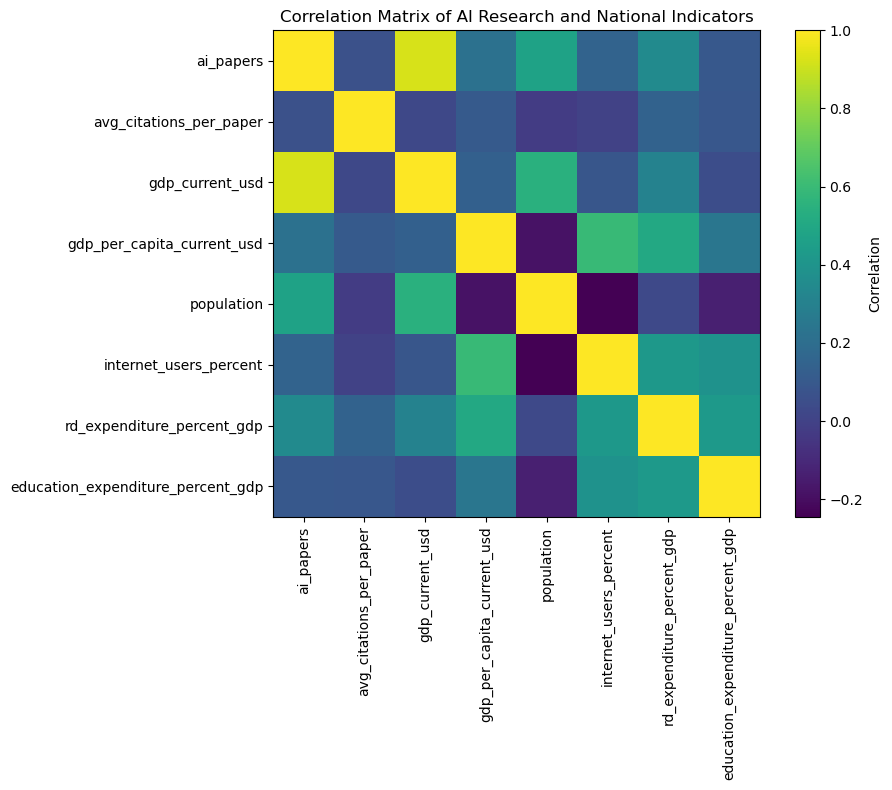

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix of AI Research and National Indicators")

plt.tight_layout()

plt.show()

In [40]:
ai_correlations = (
    correlation_matrix["ai_papers"]
    .sort_values(ascending=False)
)

ai_correlations

ai_papers                            1.000000
gdp_current_usd                      0.925659
population                           0.471434
rd_expenditure_percent_gdp           0.349900
gdp_per_capita_current_usd           0.219046
internet_users_percent               0.149900
education_expenditure_percent_gdp    0.095941
avg_citations_per_paper              0.063505
Name: ai_papers, dtype: float64

## Findings

The correlation analysis provides an overview of the relationships between AI research output and several national indicators.

Among all variables, **GDP exhibited the strongest positive correlation with AI research output (r = 0.926)**, confirming the results of the previous regression analysis. Population also demonstrated a moderate positive relationship (r ≈ 0.47), while R&D expenditure showed a weaker positive association (r ≈ 0.35).

GDP per capita, internet usage, and education expenditure displayed relatively weak positive correlations with AI research output in the current dataset.

The correlation matrix also indicates that several explanatory variables are moderately correlated with one another, particularly GDP and population, as well as GDP per capita and internet usage. These relationships should be considered when constructing multiple regression models to avoid potential multicollinearity.

Overall, the results suggest that economic size is the dominant factor associated with AI research production, while other national indicators may provide additional explanatory power when analyzed simultaneously.

# 8. Multiple Linear Regression

### Research Question

Which national characteristics are associated with AI research output when multiple factors are considered simultaneously?

### Why this matters

Previous analyses examined each variable individually. However, many national indicators are related to one another. Multiple linear regression allows us to estimate the relationship between AI research output and several explanatory variables at the same time while controlling for the influence of the others.

This provides a more comprehensive understanding of the factors associated with AI research production.

In [41]:
model_df = df[
    [
        "ai_papers",
        "gdp_current_usd",
        "population",
        "rd_expenditure_percent_gdp",
        "internet_users_percent",
        "education_expenditure_percent_gdp"
    ]
].dropna()

print(model_df.shape)
model_df.head()

(361, 6)


,ai_papers,gdp_current_usd,population,rd_expenditure_percent_gdp,internet_users_percent,education_expenditure_percent_gdp
2,6,4.339262e+11,9445785.0,1.31065,99.149998,3.860200
3,9,3.571619e+11,9401038.0,1.48831,100.000000,3.984180
4,14,4.224414e+11,9575152.0,1.49469,100.000000,3.894040
12,1,1.361929e+10,2962500.0,0.17854,66.543950,2.159842
13,1,1.387891e+10,2962300.0,0.20557,78.612258,2.767850


In [42]:
X = model_df[
    [
        "gdp_current_usd",
        "population",
        "rd_expenditure_percent_gdp",
        "internet_users_percent",
        "education_expenditure_percent_gdp"
    ]
]

y = model_df["ai_papers"]

In [43]:
from sklearn.linear_model import LinearRegression

multi_model = LinearRegression()

multi_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
print(f"R² Score: {multi_model.score(X, y):.3f}")

R² Score: 0.873


In [45]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": multi_model.coef_
})

coefficients

,Variable,Coefficient
0,gdp_current_usd,2.018706e-11
1,population,-2.139713e-08
2,rd_expenditure_percent_gdp,1.373292e+00
3,internet_users_percent,2.021954e-01
4,education_expenditure_percent_gdp,7.565530e-01


In [46]:
coefficients.sort_values(
    "Coefficient",
    ascending=False
)

,Variable,Coefficient
2,rd_expenditure_percent_gdp,1.373292e+00
4,education_expenditure_percent_gdp,7.565530e-01
3,internet_users_percent,2.021954e-01
0,gdp_current_usd,2.018706e-11
1,population,-2.139713e-08


## Standardized Regression Model

### Why standardize the predictors?

The explanatory variables are measured in different units (e.g., dollars, people, percentages). As a result, the raw regression coefficients cannot be compared directly.

To make the coefficients comparable, all predictors are standardized using z-score normalization. This transformation places every variable on the same scale (mean = 0, standard deviation = 1), allowing the magnitude of each coefficient to be interpreted as the relative importance of that predictor within the model.

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [50]:
scaled_model = LinearRegression()

scaled_model.fit(X_scaled, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
scaled_coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Standardized Coefficient": scaled_model.coef_
})

scaled_coefficients = scaled_coefficients.sort_values(
    "Standardized Coefficient",
    ascending=False
)

scaled_coefficients

,Variable,Standardized Coefficient
0,gdp_current_usd,58.483743
3,internet_users_percent,3.185247
2,rd_expenditure_percent_gdp,1.593647
4,education_expenditure_percent_gdp,1.023819
1,population,-3.897380


In [52]:
print(f"R² Score: {scaled_model.score(X_scaled, y):.3f}")

R² Score: 0.873


## Multicollinearity Assessment

### Why check multicollinearity?

Multiple regression assumes that explanatory variables are not excessively correlated with one another. Highly correlated predictors can produce unstable coefficient estimates, making it difficult to interpret the individual effect of each variable.

To evaluate this assumption, the Variance Inflation Factor (VIF) is calculated for each predictor.

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [55]:
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Variable,VIF
3,internet_users_percent,14.709592
0,gdp_current_usd,1.613910
2,rd_expenditure_percent_gdp,1.414702
1,population,1.250271
4,education_expenditure_percent_gdp,1.143693


In [56]:
from sklearn.preprocessing import StandardScaler

# Standardize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Standardize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

In [57]:
standardized_model = LinearRegression()

standardized_model.fit(X_scaled, y_scaled)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
beta = pd.DataFrame({
    "Variable": X.columns,
    "Standardized Beta": standardized_model.coef_
})

beta.sort_values(
    "Standardized Beta",
    ascending=False
)

,Variable,Standardized Beta
0,gdp_current_usd,0.941960
3,internet_users_percent,0.051303
2,rd_expenditure_percent_gdp,0.025668
4,education_expenditure_percent_gdp,0.016490
1,population,-0.062773


## Findings

A multiple linear regression model was fitted to examine the joint relationship between AI research output and several national indicators.

The model achieved an **R² score of 0.873**, indicating that approximately **87.3%** of the variation in AI research output can be explained by the included predictors.

To enable meaningful comparison between predictors, all variables were standardized before interpreting the regression coefficients.

The standardized regression coefficients indicate that:

- **GDP** is by far the strongest predictor of AI research output (β = 0.942).
- Internet usage, R&D expenditure, and education expenditure show relatively small positive associations after controlling for the other variables.
- Population exhibits a small negative association after controlling for GDP and the remaining predictors.

Overall, the results suggest that national economic size is the dominant factor associated with AI research production, while the additional variables provide only modest explanatory power within the current dataset.

# 9. Statistical Inference Using OLS Regression

### Research Question

Which national indicators remain statistically associated with AI research output after controlling for the other variables?

### Why this matters

While machine learning models provide accurate predictions, they do not report statistical significance. Ordinary Least Squares (OLS) regression provides additional inferential statistics, including p-values, confidence intervals, adjusted R², and overall model significance. These measures help evaluate whether the observed relationships are likely to reflect genuine associations rather than random variation.

In [59]:
import statsmodels.api as sm

In [60]:
X_sm = sm.add_constant(X)

In [61]:
ols_model = sm.OLS(y, X_sm).fit()

In [62]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              ai_papers   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     488.1
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          1.22e-156
Time:                        16:16:51   Log-Likelihood:                -1630.2
No. Observations:                 361   AIC:                             3272.
Df Residuals:                     355   BIC:                             3296.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

## Findings

The OLS regression model achieved an **R² of 0.873** and an **Adjusted R² of 0.871**, indicating that approximately 87% of the variation in AI research output is explained by the selected national indicators.

The overall regression model was statistically significant (**F = 488.1, p < 0.001**), suggesting that the predictors collectively provide meaningful explanatory power.

Among the explanatory variables:

- **GDP** was the strongest and most statistically significant predictor of AI research output (p < 0.001).
- **Population** showed a small but statistically significant negative association after controlling for the remaining variables (p = 0.010).
- **Internet usage** exhibited a small positive and statistically significant association (p = 0.041).
- **R&D expenditure** and **education expenditure** were not statistically significant predictors within the current dataset.

Overall, the findings suggest that economic size is the dominant factor associated with national AI research production, while the additional socioeconomic indicators contribute comparatively smaller effects after controlling for GDP.

# 10. Regression Coefficient Visualization

### Research Question

Which national indicators have the strongest association with AI research output?

### Why this matters

Although regression tables contain detailed statistical information, visualizing standardized regression coefficients makes it much easier to compare the relative importance of each predictor.

Standardized coefficients place all variables on the same scale, allowing direct comparison of their influence on AI research output.

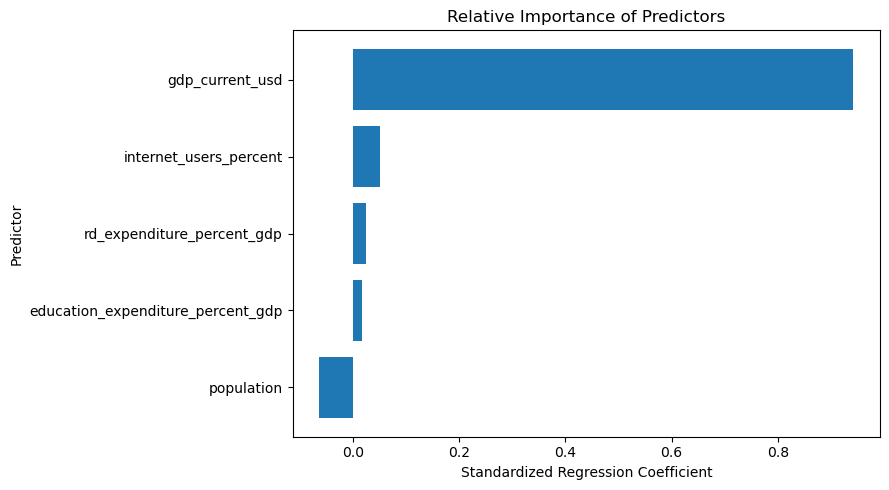

In [63]:
plt.figure(figsize=(9,5))

beta_sorted = beta.sort_values("Standardized Beta")

plt.barh(
    beta_sorted["Variable"],
    beta_sorted["Standardized Beta"]
)

plt.xlabel("Standardized Regression Coefficient")
plt.ylabel("Predictor")

plt.title("Relative Importance of Predictors")

plt.tight_layout()

plt.show()

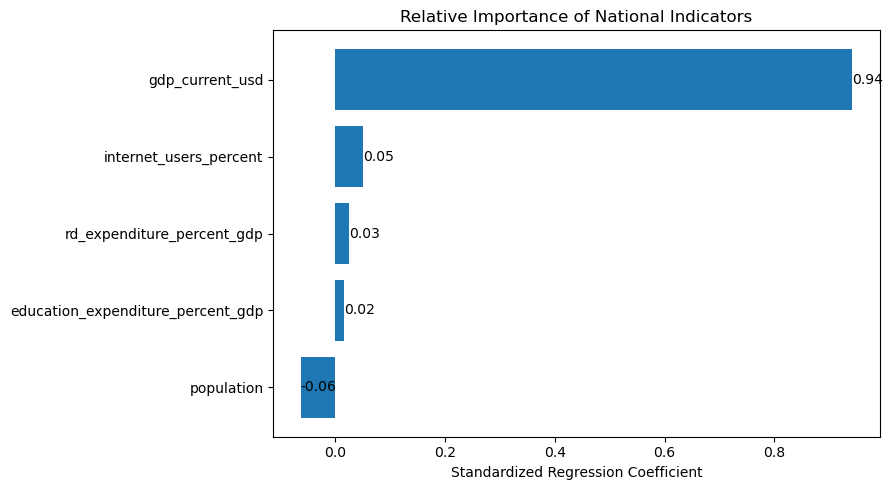

In [64]:
plt.figure(figsize=(9,5))

beta_sorted = beta.sort_values("Standardized Beta")

bars = plt.barh(
    beta_sorted["Variable"],
    beta_sorted["Standardized Beta"]
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.xlabel("Standardized Regression Coefficient")
plt.title("Relative Importance of National Indicators")

plt.tight_layout()

plt.show()

## Findings

The standardized regression coefficients confirm that GDP is the dominant predictor of AI research output.

GDP exhibits a substantially larger standardized coefficient than any other variable, indicating that national economic size explains most of the observed variation in AI publication output.

Internet penetration contributes a small positive association, while population shows a small negative association after controlling for GDP. R&D expenditure and education expenditure display comparatively weak effects in the current dataset.

Overall, the regression results reinforce the conclusion that economic capacity is the primary factor associated with national AI research productivity.